# Kaggle dataset

## Load and Read Images

In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm


In [ ]:
DATASET_DIR = "datasets/QRcodes_kaggle/QR codes"
IMG_SIZE = 29


In [3]:
def load_dataset(base_dir):
    images = []
    labels = []

    for label_name, label in [("benign", 0), ("malicious", 1)]:
        folder = os.path.join(base_dir, label_name, label_name)

        for file in tqdm(os.listdir(folder), desc=f"Loading {label_name}"):
            if file.endswith(".png"):
                path = os.path.join(folder, file)
                # print(f"Processing file: {path}")

                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                # img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0  # normalize

                images.append(img)
                labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X, y = load_dataset(DATASET_DIR)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)


FileNotFoundError: [Errno 2] No such file or directory: 'datasets/QRcodes_kaggle/benign/benign'

## Exploratory Data Analysis

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
 

In [ ]:
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = ["Benign", "Malicious"]
print(class_counts)


Benign       100000
Malicious    100000
Name: count, dtype: int64


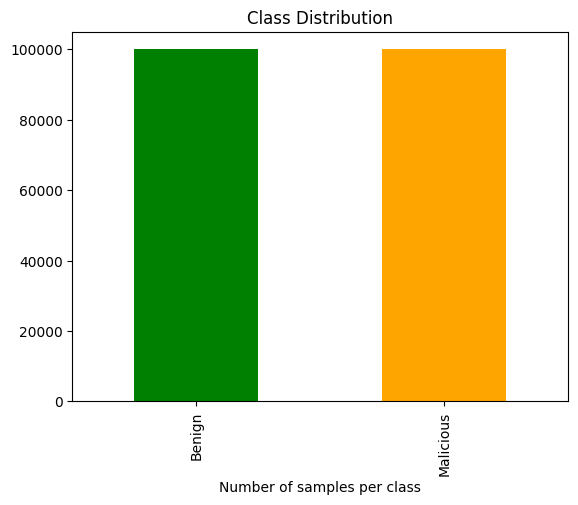

In [ ]:
class_counts.plot(kind='bar', color=['green', 'orange'])
plt.title('Class Distribution')
plt.xlabel('Number of samples per class')
plt.show()

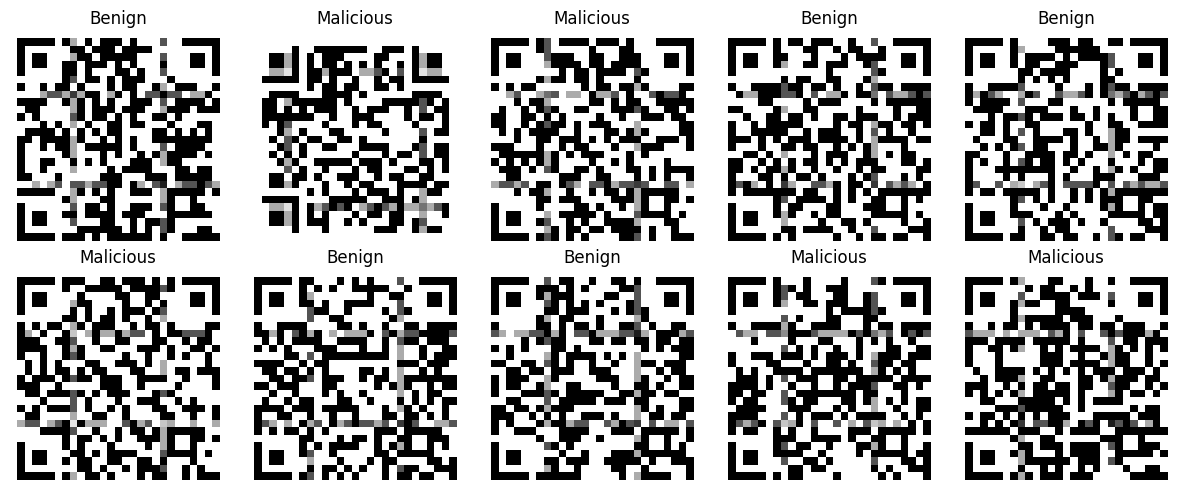

In [ ]:
import random
fig, axes  = plt.subplots(2,5, figsize=(12,5))
indices = random.sample(range(len(X)), 10)
for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(X[idx], cmap='gray')
    ax.set_title("Malicious" if y[idx] == 1 else "Benign")
    ax.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
print("Pixel value range:", X.min(), "to", X.max())
print("Mean pixel value:", X.mean())
print("Standard deviation of pixel values:", X.std())


Pixel value range: 0.0 to 1.0
Mean pixel value: 0.5853799168123845
Standard deviation of pixel values: 0.4783498150761924


In [ ]:
X_flat = X.reshape(X.shape[0], -1)
print("Flattened images shape:", X_flat.shape)
x= 29*29
x

Flattened images shape: (200000, 841)


841

In [ ]:
# Saving the prepared dataset for CNN/fusion models
import pickle
with open ("qr_codes_29_kaggle.pkl", "wb") as f:
    pickle.dump(X, f)
    
with open ("qr_codes_labels_kaggle.pkl", "wb") as f:
    pickle.dump(y, f)

In [ ]:
# saving the prepared dataset for classical baseline ML models
with open ("qr_codes_29_kaggle_flat.pkl", "wb") as f:
    pickle.dump(X_flat, f)
    
with open ("qr_codes_labels_kaggle.pkl", "wb") as f:
    pickle.dump(y, f)

# CIC Trap4Phish

In [ ]:
trap4phish_dir = "datasets/QRcodes_CIC_trap4phish"